Part 0: Repository Setup

In [3]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

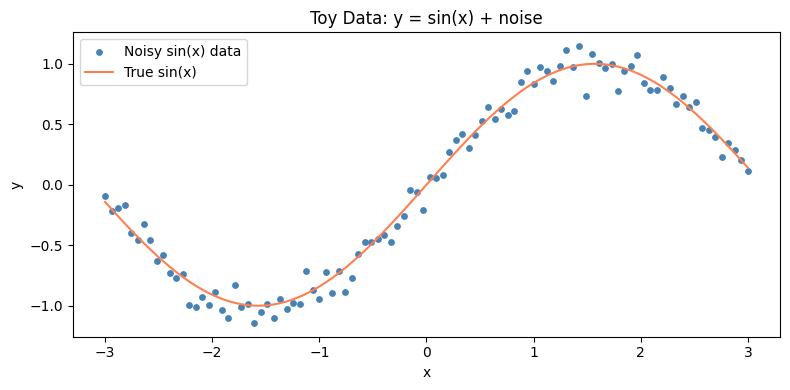

Final w = 0.3390,  b = -0.0104
Final loss = 0.1955


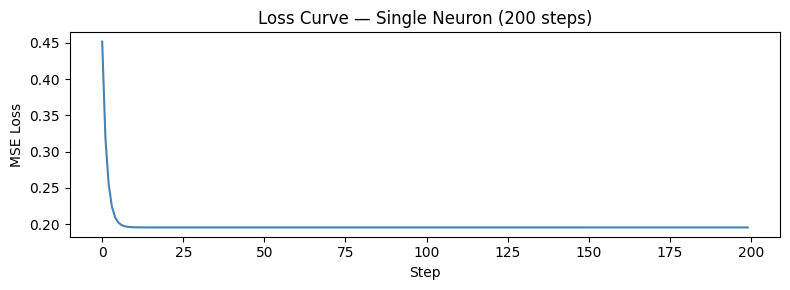

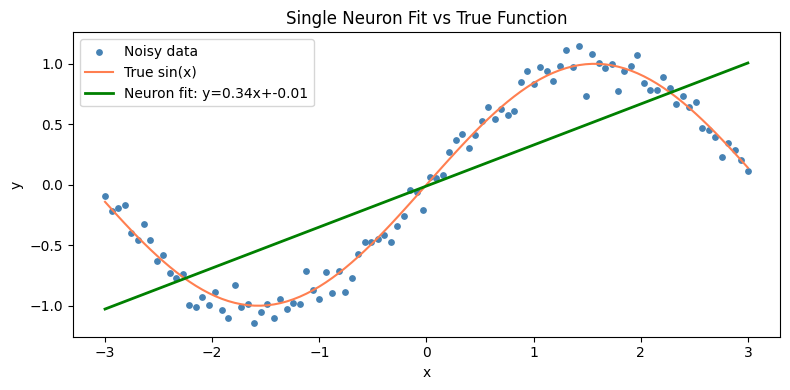

In [4]:
# Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# The plot of the raw data
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy sin(x) data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.title('Toy Data: y = sin(x) + noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

# Initialise w and b to small random values
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr     = 0.05
steps  = 200
losses = []

# Gradient descent loop
for step in range(steps):
    # Forward pass: single neuron prediction
    y_hat = w * x + b

    # Loss: Mean Squared Error
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients (derived from MSE loss by chain rule)
    dw = np.mean(2 * (y_hat - y) * x)   # dLoss/dw
    db = np.mean(2 * (y_hat - y))        # dLoss/db

    # Parameter update
    w -= lr * dw
    b -= lr * db

print(f"Final w = {w:.4f},  b = {b:.4f}")
print(f"Final loss = {losses[-1]:.4f}")

# Plot (a): Loss curve
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.title('Loss Curve — Single Neuron (200 steps)')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

# Plot (b): Data with fitted line
y_final = w * x + b

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.plot(x, y_final, color='green', linewidth=2, label=f'Neuron fit: y={w:.2f}x+{b:.2f}')
plt.title('Single Neuron Fit vs True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**

**1. Deriving dLoss/dw:**

Loss = (1/n) * Σ(y_hat - y)²    where y_hat = w*x + b

dLoss/dw = (1/n) * Σ 2(y_hat - y) * x

It matches the code:
dw = np.mean(2 * (y_hat - y) * x)  

**2. Underfitting or overfitting?**

This is underfitting. The loss curve shows the loss dropping quickly
from 0.45 and becoming flattened at 0.20
no matter how many more steps are run. The fit plot confirms this: the
neuron learned y = 0.34x - 0.01, a straight line that cuts through the
middle of the data but completely misses the curve. A single neuron
can never fit a sine wave because it can only compute w*x + b, which
is always a straight line. Sin(x) curves up, peaks, and curves back
down, no straight line can represent that shape no matter of how
long we continued training it.

Part 1.2 — Hidden layers and activations: why depth helps

Final loss WITH tanh: 0.010999


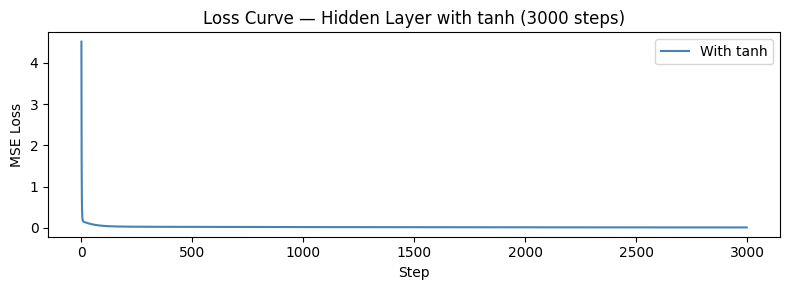

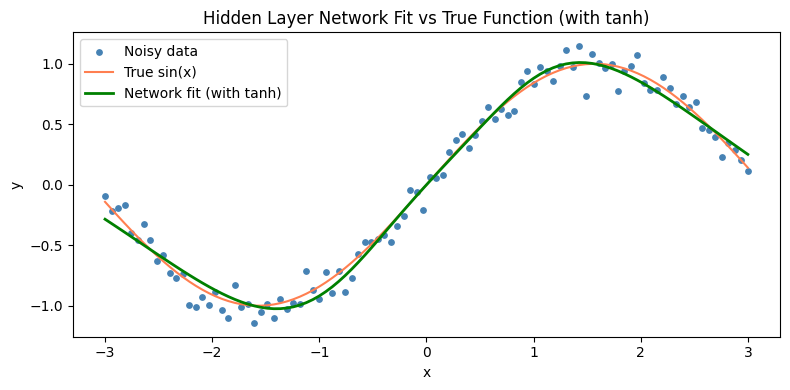

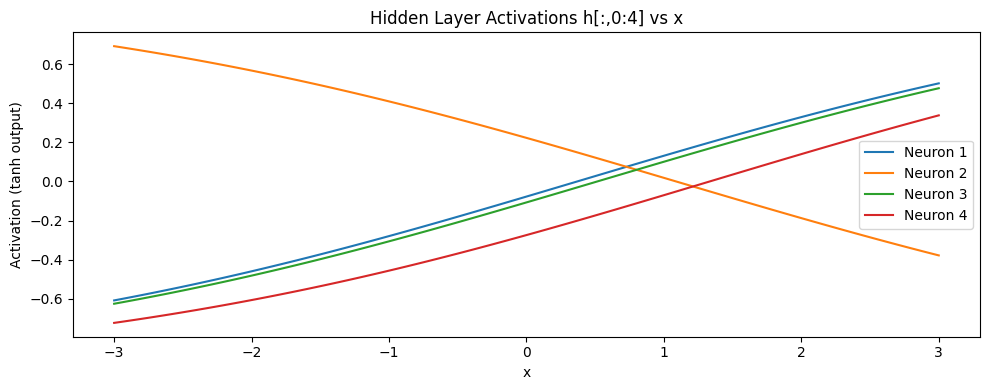

Final loss WITHOUT tanh (linear): 0.195452


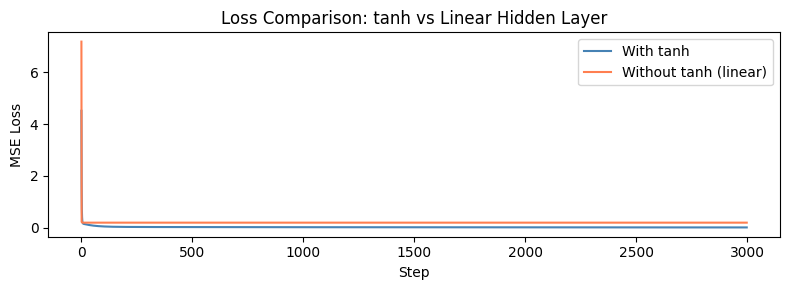

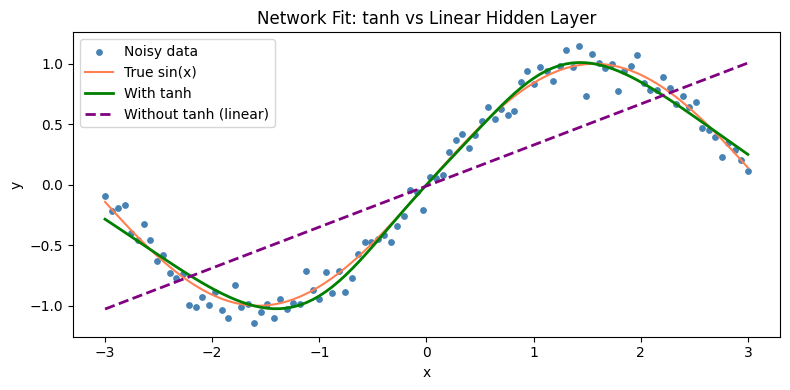

In [5]:
# Part 1.2: Hidden layers and activations

# Reshape x for matrix operations
x_col = x.reshape(-1, 1)   # shape (100, 1)
y_col = y.reshape(-1, 1)   # shape (100, 1)

# Initialise parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5   # shape (1, 8)
b1 = np.random.randn(8)    * 0.5   # shape (8,)
W2 = np.random.randn(8, 1) * 0.5   # shape (8, 1)
b2 = np.random.randn(1)    * 0.5   # shape (1,)

lr     = 0.05
steps  = 3000
losses = []

# Training loop WITH tanh
for step in range(steps):

    # Forward pass
    z1    = x_col @ W1 + b1          # shape (100, 8)
    h     = np.tanh(z1)              # shape (100, 8)
    y_hat = h @ W2 + b2              # shape (100, 1)
    loss  = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    # Backward pass (chain rule layer by layer)
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # shape (100, 1)
    dW2    = h.T @ d_yhat                         # shape (8, 1)
    db2    = d_yhat.sum(axis=0)                   # shape (1,)
    dh     = d_yhat @ W2.T                        # shape (100, 8)
    dz1    = dh * (1 - np.tanh(z1) ** 2)         # shape (100, 8)
    dW1    = x_col.T @ dz1                        # shape (1, 8)
    db1    = dz1.sum(axis=0)                      # shape (8,)

    # Parameter updates
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

print(f"Final loss WITH tanh: {losses[-1]:.6f}")

# Plot (a): Loss curve WITH tanh
plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue', label='With tanh')
plt.title('Loss Curve — Hidden Layer with tanh (3000 steps)')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot (b): Final fit WITH tanh
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x), color='coral', linewidth=1.5, label='True sin(x)')
plt.plot(x, y_hat.flatten(), color='green', linewidth=2, label='Network fit (with tanh)')
plt.title('Hidden Layer Network Fit vs True Function (with tanh)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

# Plot a few columns of h to show what each neuron learned
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(x, h[:, i], label=f'Neuron {i+1}')
plt.title('Hidden Layer Activations h[:,0:4] vs x')
plt.xlabel('x')
plt.ylabel('Activation (tanh output)')
plt.legend()
plt.tight_layout()
plt.show()

# Re-run WITHOUT tanh (h = z1, purely linear)
np.random.seed(RANDOM_STATE)
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.random.randn(8)    * 0.5
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.random.randn(1)    * 0.5

losses_linear = []

for step in range(steps):

    # Forward pass — NO tanh, h = z1
    z1_lin    = x_col @ W1_lin + b1_lin
    h_lin     = z1_lin                           # linear activation
    y_hat_lin = h_lin @ W2_lin + b2_lin
    loss_lin  = np.mean((y_hat_lin - y_col) ** 2)
    losses_linear.append(loss_lin)

    # Backward pass
    d_yhat_lin = 2 * (y_hat_lin - y_col) / len(y_col)
    dW2_lin    = h_lin.T @ d_yhat_lin
    db2_lin    = d_yhat_lin.sum(axis=0)
    dh_lin     = d_yhat_lin @ W2_lin.T
    dz1_lin    = dh_lin                          # derivative of linear = 1
    dW1_lin    = x_col.T @ dz1_lin
    db1_lin    = dz1_lin.sum(axis=0)

    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin
    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin

print(f"Final loss WITHOUT tanh (linear): {losses_linear[-1]:.6f}")

# Plot both loss curves together
plt.figure(figsize=(8, 3))
plt.plot(losses,        color='steelblue', label='With tanh')
plt.plot(losses_linear, color='coral',     label='Without tanh (linear)')
plt.title('Loss Comparison: tanh vs Linear Hidden Layer')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Final fit WITHOUT tanh
plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=15, color='steelblue', label='Noisy data')
plt.plot(x, np.sin(x),          color='coral',     linewidth=1.5, label='True sin(x)')
plt.plot(x, y_hat.flatten(),    color='green',     linewidth=2,   label='With tanh')
plt.plot(x, y_hat_lin.flatten(), color='purple',   linewidth=2,   linestyle='--', label='Without tanh (linear)')
plt.title('Network Fit: tanh vs Linear Hidden Layer')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Depth and activations**

**1. Why a stack of linear layers collapses into one linear layer:**

Without tanh, each layer computes: output = input * W + b.
If we stack two linear layers:
  Layer 1: z1 = x * W1 + b1
  Layer 2: y_hat = z1 * W2 + b2
           y_hat = (x * W1 + b1) * W2 + b2
           y_hat = x * (W1 * W2) + (b1 * W2 + b2)

This is just x * W_combined + b_combined, a single linear function.
No matter how many layers you stack, the result is always just w*x + b.
The loss comparison plot confirms this, without tanh, the final loss
is 0.1955, identical to the single neuron in Part 1.1. The dashed
purple line in the fit plot is just a straight line, the same as
Part 1.1's green line.

**2. What the 8 hidden neurons did:**

The activation plot shows each neuron learned a different S-shaped
tanh curve with a different slope and crossing point. Neuron 2 (orange)
starts high and decreases, while Neurons 1, 3, and 4 start low and
increase at slightly different rates. The output layer combined these
8 different curved shapes with learned weights to produce the final
sine-shaped prediction. This is why the network with tanh achieved
a final loss of 0.011, nearly 18 times better than the linear
version (0.195). The hidden neurons act as building blocks, each
contributing a different curved piece that together approximate sin(x).

**3. What is backpropagation?**

Backpropagation is the process of computing how much each weight
contributed to the final loss by applying the chain rule backwards
through every layer, so each weight knows exactly how to update
itself to reduce the loss.

Part 1.3 — The learning rate: too cold, too hot, just right

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_5206/912050589.py:21: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_5206/912050589.py:28: RuntimeWarning: overflow encountered in matmul
  dh     = d_yhat @ W2.T
/tmp/ipykernel_5206/912050589.py:29: RuntimeWarning: invalid value encountered in multiply
  dz1    = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


Final loss (lr=0.001): 0.071819
Final loss (lr=0.05):  0.010999
Final loss (lr=1.0):   nan


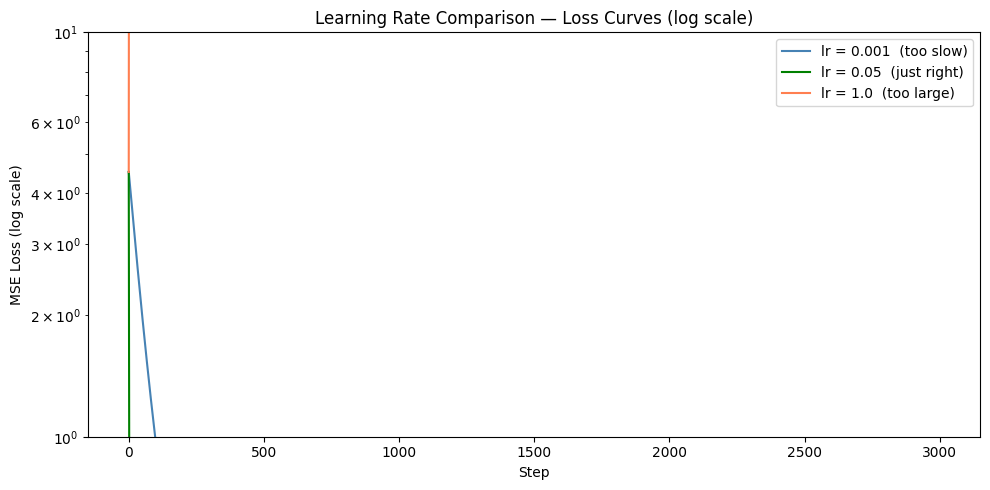

In [6]:
# Part 1.3: The learning rate — too cold, too hot, just right

def train_toy(lr, steps=3000):
    """Train the Part 1.2 network with a given learning rate.
    Resets the seed before every run for a fair comparison."""

    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8)    * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1)    * 0.5

    losses = []

    for step in range(steps):

        # Forward pass
        z1    = x_col @ W1 + b1
        h     = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss  = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2    = h.T @ d_yhat
        db2    = d_yhat.sum(axis=0)
        dh     = d_yhat @ W2.T
        dz1    = dh * (1 - np.tanh(z1) ** 2)
        dW1    = x_col.T @ dz1
        db1    = dz1.sum(axis=0)

        # Parameter update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return losses

# Run with three learning rates
lr_slow   = 0.001
lr_good   = 0.05
lr_large  = 1.0

losses_slow  = train_toy(lr=lr_slow)
losses_good  = train_toy(lr=lr_good)
losses_large = train_toy(lr=lr_large)

print(f"Final loss (lr=0.001): {losses_slow[-1]:.6f}")
print(f"Final loss (lr=0.05):  {losses_good[-1]:.6f}")
print(f"Final loss (lr=1.0):   {losses_large[-1]:.6f}")

# Plot all three on the same axes (log scale on y)
plt.figure(figsize=(10, 5))
plt.plot(losses_slow,  color='steelblue', label=f'lr = {lr_slow}  (too slow)')
plt.plot(losses_good,  color='green',     label=f'lr = {lr_good}  (just right)')
plt.plot(losses_large, color='coral',     label=f'lr = {lr_large}  (too large)')
plt.yscale('log')
plt.title('Learning Rate Comparison — Loss Curves (log scale)')
plt.xlabel('Step')
plt.ylabel('MSE Loss (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

**Student Reasoning - Learning rate**

**lr = 0.001 (too slow - blue):**
The loss starts dropping but is still at 0.072 after 3000 steps,
which is much worse than lr=0.05 achieved. The curve is descending
so slowly that 3000 steps are not enough to reach a good solution.
With more steps it would eventually get there, but it is far too
inefficient in practice.

**lr = 0.05 (just right - green):**
The loss drops steeply in the first ~100 steps and flattens out
near 0.011, the best result of all three. This matches what we
saw in Part 1.2. The step size is small enough to follow the slope
of the loss surface smoothly without overshooting.

**lr = 1.0 (too large - orange):**
The loss immediately explodes to NaN (not a number), confirmed by
the overflow warnings. The curve shoots up off the chart in the
very first step and never recovers. Final loss = nan.

**Why a too-large learning rate explodes instead of just learning faster:**
Gradient descent moves in the direction of the negative gradient by
a step of size lr * gradient. When lr is too large, each update
overshoots the minimum, instead of landing near the bottom of the
loss curve, the weights jump past it to a worse position on the
other side. The gradient there is even larger, so the next step
overshoots even further. This keeps amplifying until the values
overflow to infinity and then NaN. A large lr does not speed up
learning, it destroys it by making updates too aggressive to
ever settle at a minimum.

Section 2 — A Real Feedforward Network in PyTorch

Part 2.1 — Preprocess and split (recycled from Lab 2)

In [7]:
# Part 2.1: Preprocess and split

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load data
obesity = pd.read_csv(OBESITY_URL)
print("Shape:", obesity.shape)

# Encode categoricals (same as Lab 2)
obesity_clean = obesity.copy()

# Binary yes/no columns → 0/1
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_clean[col] = obesity_clean[col].map({'yes': 1, 'no': 0})

# Gender → 0/1
obesity_clean['Gender'] = obesity_clean['Gender'].map({'Male': 1, 'Female': 0})

# Ordinal columns: natural order preserved
caec_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
calc_order  = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity_clean['CAEC'] = obesity_clean['CAEC'].map(caec_order)
obesity_clean['CALC'] = obesity_clean['CALC'].map(calc_order)

# Nominal column: MTRANS → one-hot
obesity_clean = pd.get_dummies(obesity_clean, columns=['MTRANS'], drop_first=True)

# Feature engineering: BMI
obesity_clean['BMI'] = obesity_clean['Weight'] / (obesity_clean['Height'] ** 2)

print("Shape after encoding:", obesity_clean.shape)

# Encode target
le = LabelEncoder()
y_all = le.fit_transform(obesity_clean['NObeyesdad'])
X_all = obesity_clean.drop(columns=['NObeyesdad'])

print("Target classes:", le.classes_)
print("Features shape:", X_all.shape)

# Stratified 60/20/20 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Scale: fit on train only, transform all three
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Scaling complete.")

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)

X_val_t   = torch.tensor(X_val_sc,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,      dtype=torch.long)

X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)

# Wrap in DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=32,
    shuffle=False
)

input_dim = X_train_t.shape[1]
print(f"\nInput dimension: {input_dim}")
print(f"Train batches:   {len(train_loader)}")
print(f"Val batches:     {len(val_loader)}")
print(f"Test batches:    {len(test_loader)}")

Shape: (2111, 17)
Shape after encoding: (2111, 21)
Target classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
Features shape: (2111, 20)

Train: 1266 | Val: 422 | Test: 423
Scaling complete.

Input dimension: 20
Train batches:   40
Val batches:     14
Test batches:    14


**Student Reasoning - Preprocessing for neural networks**

**1. Why CrossEntropyLoss needs integer labels, not one-hot vectors:**
PyTorch's CrossEntropyLoss internally handles the one-hot conversion
itself - it takes a raw integer class index (e.g. 3) and looks up the
correct position to compute the log probability against. If you passed
a one-hot vector instead, PyTorch would not know how to interpret it
as a class index and would throw an error. Using integers is also more
memory efficient since storing one number per sample is cheaper than
storing 7 numbers per sample.

**2. Why neural networks care about feature scaling:**
In Section 1, the gradient formulas were:
  dw = mean(2 * (y_hat - y) * x)
  dW1 = x.T @ dz1

The gradient of every weight is directly multiplied by x. If one
feature has values in the thousands (like Weight in kg) and another
has values near 0 (like Height in metres), the gradients for the
large-scale feature will be enormous and the gradients for the
small-scale feature will be tiny. This causes the network to update
some weights far too aggressively and barely update others, making
training unstable. A random forest splits on feature values one at
a time and is not affected by scale, but a neural network mixes all
features together through matrix multiplication, so unequal scales
directly distort every gradient.

**3. What shuffle=True does and why it helps:**
shuffle=True randomly reorders the training data at the start of
every epoch before dividing it into batches. Without shuffling, the
model would see the same batches in the same order every epoch, which
can cause it to memorise the order rather than the actual patterns.
Shuffling ensures each batch contains a random mix of examples across
all classes, which makes gradient estimates less noisy and helps the
model generalise better.

Part 2.2 — Design the network

In [8]:
# Part 2.2: Design the network

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        # Build layers dynamically from hidden_sizes
        layers = []
        in_dim = input_dim

        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))  # fully connected layer
            layers.append(nn.ReLU())                  # non-linear activation
            in_dim = h_dim

        # Output layer: produces 7 raw logits (no softmax)
        layers.append(nn.Linear(in_dim, n_classes))

        # Pack everything into a sequential container
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Instantiate the model
model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
).to(DEVICE)

# Print model architecture
print("Model architecture:")
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params}")

# Verify first layer by hand
layer1_weights = input_dim * 64
layer1_biases  = 64
layer1_total   = layer1_weights + layer1_biases

layer2_weights = 64 * 32
layer2_biases  = 32
layer2_total   = layer2_weights + layer2_biases

layer3_weights = 32 * 7
layer3_biases  = 7
layer3_total   = layer3_weights + layer3_biases

hand_total = layer1_total + layer2_total + layer3_total

print(f"\nBy-hand parameter count:")
print(f"  Layer 1 (Linear {input_dim}→64):  {input_dim} × 64 + 64 = {layer1_total}")
print(f"  Layer 2 (Linear 64→32):   64 × 32 + 32  = {layer2_total}")
print(f"  Layer 3 (Linear 32→7):    32 × 7  + 7   = {layer3_total}")
print(f"  Total (by hand):           {hand_total}")
print(f"  Total (PyTorch):           {total_params}")
print(f"  Match: {hand_total == total_params}")

Model architecture:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Total trainable parameters: 3655

By-hand parameter count:
  Layer 1 (Linear 20→64):  20 × 64 + 64 = 1344
  Layer 2 (Linear 64→32):   64 × 32 + 32  = 2080
  Layer 3 (Linear 32→7):    32 × 7  + 7   = 231
  Total (by hand):           3655
  Total (PyTorch):           3655
  Match: True


**Student Reasoning — Architecture**

**1. By-hand parameter count:**

Layer 1 (Linear 20→64):  20 × 64 weights + 64 biases  = 1,344
Layer 2 (Linear 64→32):  64 × 32 weights + 32 biases  = 2,080
Layer 3 (Linear 32→7):   32 × 7  weights + 7  biases  =   231

Total by hand: 1,344 + 2,080 + 231 = 3,655
Total PyTorch: 3,655
Match: True

**2. Why ReLU instead of tanh:**
ReLU computes max(0, x) - it simply passes positive values through
and sets negative values to zero. One key advantage over tanh is that
ReLU does not suffer from the vanishing gradient problem in deep
networks. With tanh, the gradient (1 - tanh²(z)) becomes very close
to zero when z is large or very negative, which slows down or stops
learning in earlier layers. ReLU's gradient is either 0 or 1 for
positive inputs, so gradients flow back through the network much more
cleanly. ReLU is also cheaper to compute since it requires no
exponential operations.

**3. What the network would compute without ReLUs:**
Without ReLUs, every layer is just a linear transformation. As proved
in Part 1.2, stacking linear layers always collapses into a single
linear function, no matter how many layers you add. The network
would be equivalent to one single Linear(20→7) layer and could only
learn linear decision boundaries, which is not powerful enough to
separate the 7 obesity classes correctly.

Part 2.3 — The training loop

Epoch   1/50 | Train Loss: 1.7390  Train Acc: 0.4171 | Val Loss:   1.7458  Val Acc:   0.3839
Epoch   2/50 | Train Loss: 1.3528  Train Acc: 0.6303 | Val Loss:   1.3669  Val Acc:   0.6232
Epoch   3/50 | Train Loss: 0.9740  Train Acc: 0.6627 | Val Loss:   0.9880  Val Acc:   0.6611
Epoch   4/50 | Train Loss: 0.7697  Train Acc: 0.7409 | Val Loss:   0.7921  Val Acc:   0.7393
Epoch   5/50 | Train Loss: 0.6265  Train Acc: 0.8025 | Val Loss:   0.6570  Val Acc:   0.7986
Epoch   6/50 | Train Loss: 0.5314  Train Acc: 0.8515 | Val Loss:   0.5655  Val Acc:   0.8294
Epoch   7/50 | Train Loss: 0.4402  Train Acc: 0.8776 | Val Loss:   0.4894  Val Acc:   0.8507
Epoch   8/50 | Train Loss: 0.3771  Train Acc: 0.8997 | Val Loss:   0.4378  Val Acc:   0.8673
Epoch   9/50 | Train Loss: 0.3297  Train Acc: 0.9123 | Val Loss:   0.4033  Val Acc:   0.8602
Epoch  10/50 | Train Loss: 0.2960  Train Acc: 0.9139 | Val Loss:   0.3761  Val Acc:   0.8720
Epoch  11/50 | Train Loss: 0.2597  Train Acc: 0.9273 | Val Loss:   0.3

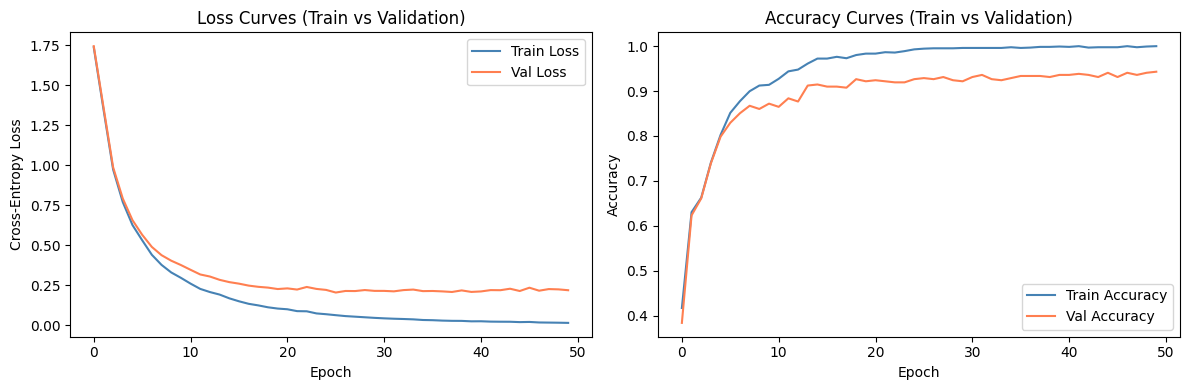

In [9]:
# Part 2.3: The training loop

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# History tracking
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_acc  = 0.0
EPOCHS        = 50

# Helper: evaluate on a full dataset (no gradient needed)
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb   = xb.to(DEVICE), yb.to(DEVICE)
            logits   = model(xb)
            loss     = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            preds    = logits.argmax(dim=1)
            correct  += (preds == yb).sum().item()
            total    += len(yb)
    return total_loss / total, correct / total

# Training loop
for epoch in range(1, EPOCHS + 1):

    # Training phase
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()              # clear old gradients
        logits = model(xb)                 # forward pass
        loss   = criterion(logits, yb)     # compute loss
        loss.backward()                    # backprop: compute gradients
        optimizer.step()                   # update weights

    # Evaluation phase
    train_loss, train_acc = evaluate(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    # One-line summary per epoch
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f} | "
          f"Val Loss:   {val_loss:.4f}  Val Acc:   {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print("Best model saved to ffn_best.pt")

# --- Plot loss curves ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], color='steelblue', label='Train Loss')
plt.plot(history['val_loss'],   color='coral',     label='Val Loss')
plt.title('Loss Curves (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()

# --- Plot accuracy curves ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], color='steelblue', label='Train Accuracy')
plt.plot(history['val_acc'],   color='coral',     label='Val Accuracy')
plt.title('Accuracy Curves (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Training**

1. Mapping PyTorch lines to Section 1 NumPy code:

PyTorch line                    → Section 1 equivalent
─────────────────────────────────────────────────────
logits = model(xb)              → z1 = x @ W1 + b1; h = tanh(z1); y_hat = h @ W2 + b2
loss = criterion(logits, yb)    → loss = np.mean((y_hat - y) ** 2)
loss.backward()                 → dW2 = h.T @ d_yhat; dW1 = x.T @ dz1 (chain rule)
optimizer.step()                → W1 -= lr * dW1; W2 -= lr * dW2
optimizer.zero_grad()           → (no equivalent needed in NumPy since we overwrote
                                   dw and db each step — PyTorch accumulates instead)

**2. Overfitting, underfitting, or well-fitted?**

The model shows mild overfitting. By epoch 50, Train Acc = 1.0000
and Train Loss = 0.0140, while Val Acc = 0.9431 and Val Loss = 0.2184.
The training accuracy reaches perfect but validation plateaus around
0.93-0.94 from epoch 25 onwards, and the validation loss stops
improving while training loss keeps falling. The gap between train
loss (0.014) and val loss (0.218), more than 15x, confirms the
model is starting to memorise the training data. However the val
accuracy of 94.3% is still strong, so the overfitting is mild
rather than severe.

**3. Why optimizer.zero_grad() is called every batch:**

PyTorch accumulates gradients by default - every call to
loss.backward() adds the new gradients on top of whatever gradients
are already stored in each parameter. Without zero_grad(), the
gradients from batch 1 would still be present when batch 2 runs,
so the update would be based on the sum of all previous batches
rather than just the current one. This silently makes each update
larger and larger as training continues, causing unstable or
incorrect weight updates. Calling zero_grad() at the start of each
batch resets all stored gradients to zero so each batch gets a
clean, correct gradient estimate.

Part 2.4 — Experiments: how training choices change the outcome

=== Experiment A: Capacity ===
  hidden=(8,) lr=0.001 dropout=0.0 | Final Val Acc: 0.8318  Val Loss: 0.4695
  hidden=(64, 32) lr=0.001 dropout=0.0 | Final Val Acc: 0.9431  Val Loss: 0.2184
  hidden=(256, 128, 64) lr=0.001 dropout=0.0 | Final Val Acc: 0.9431  Val Loss: 0.2642


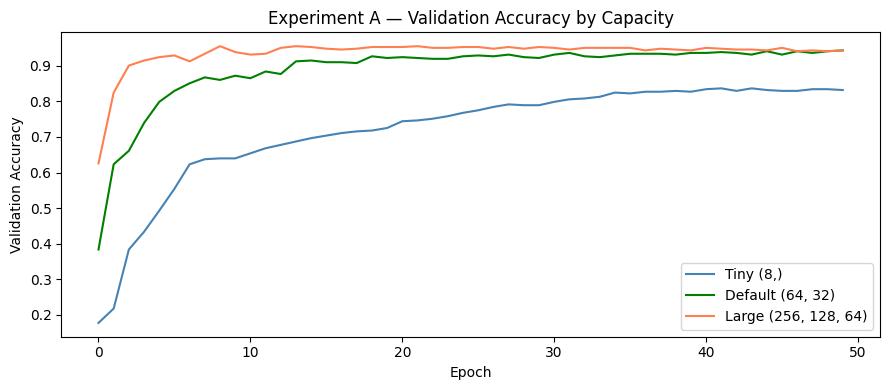


=== Experiment B: Learning Rate ===
  hidden=(64, 32) lr=0.0001 dropout=0.0 | Final Val Acc: 0.8175  Val Loss: 0.6343
  hidden=(64, 32) lr=0.001 dropout=0.0 | Final Val Acc: 0.9431  Val Loss: 0.2184
  hidden=(64, 32) lr=0.1 dropout=0.0 | Final Val Acc: 0.3555  Val Loss: 2.1470


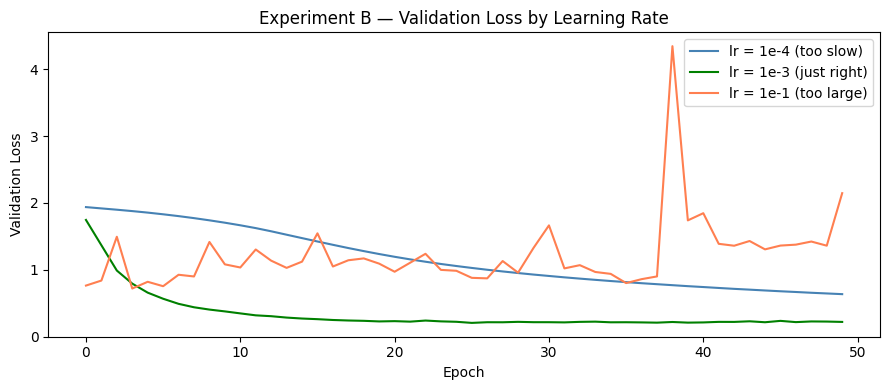


=== Experiment C: Regularization (Dropout) ===
  hidden=(256, 128, 64) lr=0.001 dropout=0.0 | Final Val Acc: 0.9431  Val Loss: 0.2642
  hidden=(256, 128, 64) lr=0.001 dropout=0.3 | Final Val Acc: 0.9455  Val Loss: 0.2277


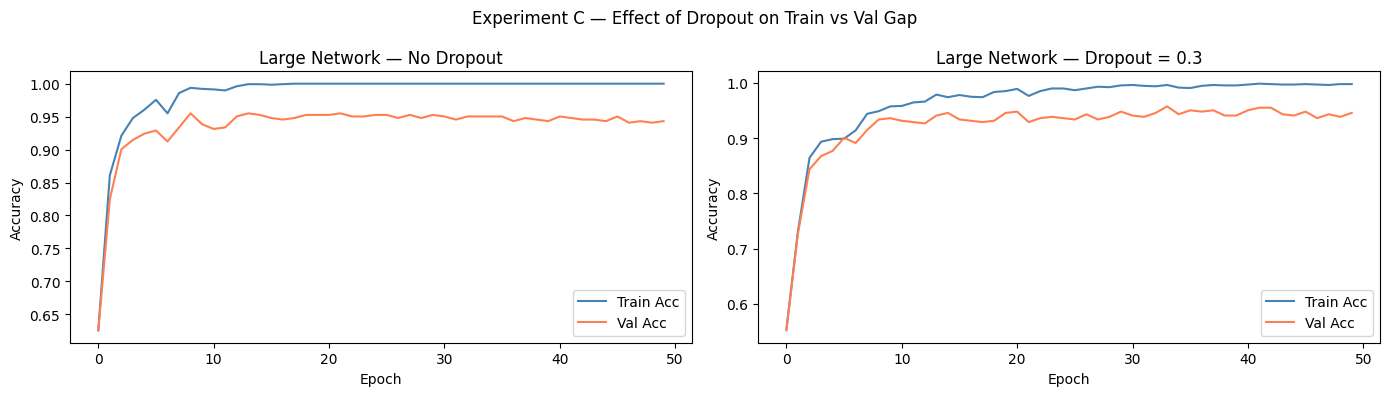

In [10]:
# Part 2.4: Experiments

class FeedForwardNetWithDropout(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32,
                   epochs=50, dropout=0.0):
    """Train a fresh model with given settings. Returns history dict."""

    # Fresh DataLoader with chosen batch size
    train_ld = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True
    )

    # Fresh model
    net = FeedForwardNetWithDropout(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout
    ).to(DEVICE)

    criterion_exp = nn.CrossEntropyLoss()
    optimizer_exp = torch.optim.Adam(net.parameters(), lr=lr)

    def eval_net(loader):
        net.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = net(xb)
                loss   = criterion_exp(logits, yb)
                total_loss += loss.item() * len(yb)
                preds  = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total   += len(yb)
        return total_loss / total, correct / total

    history_exp = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  []
    }

    for epoch in range(1, epochs + 1):
        net.train()
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_exp.zero_grad()
            logits = net(xb)
            loss   = criterion_exp(logits, yb)
            loss.backward()
            optimizer_exp.step()

        train_loss, train_acc = eval_net(train_ld)
        val_loss,   val_acc   = eval_net(val_loader)

        history_exp['train_loss'].append(train_loss)
        history_exp['val_loss'].append(val_loss)
        history_exp['train_acc'].append(train_acc)
        history_exp['val_acc'].append(val_acc)

    print(f"  hidden={hidden_sizes} lr={lr} dropout={dropout} | "
          f"Final Val Acc: {val_acc:.4f}  Val Loss: {val_loss:.4f}")

    return history_exp


# Experiment A: Capacity
print("=== Experiment A: Capacity ===")
torch.manual_seed(RANDOM_STATE)
hist_tiny  = run_experiment(hidden_sizes=(8,),           lr=1e-3, epochs=50)
torch.manual_seed(RANDOM_STATE)
hist_def   = run_experiment(hidden_sizes=(64, 32),       lr=1e-3, epochs=50)
torch.manual_seed(RANDOM_STATE)
hist_large = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, epochs=50)

plt.figure(figsize=(9, 4))
plt.plot(hist_tiny['val_acc'],  color='steelblue', label='Tiny (8,)')
plt.plot(hist_def['val_acc'],   color='green',     label='Default (64, 32)')
plt.plot(hist_large['val_acc'], color='coral',     label='Large (256, 128, 64)')
plt.title('Experiment A — Validation Accuracy by Capacity')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Experiment B: Learning Rate
print("\n=== Experiment B: Learning Rate ===")
torch.manual_seed(RANDOM_STATE)
hist_slow = run_experiment(hidden_sizes=(64, 32), lr=1e-4, epochs=50)
torch.manual_seed(RANDOM_STATE)
hist_good = run_experiment(hidden_sizes=(64, 32), lr=1e-3, epochs=50)
torch.manual_seed(RANDOM_STATE)
hist_fast = run_experiment(hidden_sizes=(64, 32), lr=1e-1, epochs=50)

plt.figure(figsize=(9, 4))
plt.plot(hist_slow['val_loss'], color='steelblue', label='lr = 1e-4 (too slow)')
plt.plot(hist_good['val_loss'], color='green',     label='lr = 1e-3 (just right)')
plt.plot(hist_fast['val_loss'], color='coral',     label='lr = 1e-1 (too large)')
plt.title('Experiment B — Validation Loss by Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Experiment C: Regularization (Dropout)
print("\n=== Experiment C: Regularization (Dropout) ===")
torch.manual_seed(RANDOM_STATE)
hist_no_drop = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3,
                               epochs=50, dropout=0.0)
torch.manual_seed(RANDOM_STATE)
hist_drop    = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3,
                               epochs=50, dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_no_drop['train_acc'], color='steelblue', label='Train Acc')
axes[0].plot(hist_no_drop['val_acc'],   color='coral',     label='Val Acc')
axes[0].set_title('Large Network — No Dropout')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(hist_drop['train_acc'], color='steelblue', label='Train Acc')
axes[1].plot(hist_drop['val_acc'],   color='coral',     label='Val Acc')
axes[1].set_title('Large Network — Dropout = 0.3')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Experiment C — Effect of Dropout on Train vs Val Gap')
plt.tight_layout()
plt.show()

**Student Reasoning - Experiments**

**1. Capacity (Experiment A):**
The largest network (256, 128, 64) did not clearly win. Looking at the
plot, the large network (orange) converges fastest, it reaches 0.90+
by epoch 3, but ends at the same final val acc (0.9431) as the default
(64, 32). The tiny network (8,) only reaches 0.8318 after 50 epochs
and is still slowly improving, showing it lacks enough capacity. The
jump from tiny to default is large (0.8318 → 0.9431), but going from
default to large gives zero improvement in accuracy and worse val loss
(0.2642 vs 0.2184). This is diminishing returns, the dataset is too
small to benefit from the extra parameters in the large network.

**2. Learning rate (Experiment B):**
The three regimes match Part 1.3 exactly. lr=1e-4 (blue) descends
very slowly and is still at 0.64 val loss after 50 epochs, never
converging, same as the slow blue curve in Part 1.3. lr=1e-3 (green)
converges cleanly to the best val loss of 0.22, same as the "just
right" curve. lr=1e-1 (orange) oscillates wildly, spiking as high as
4.3 at epoch 37, ending at 2.15 val loss, the same unstable exploding
behaviour seen with lr=1.0 in the toy problem. The only difference is
that here the model does not fully diverge to NaN because Adam's
adaptive learning rate partially cushions the large updates.

**3. Regularization (Experiment C):**
Without dropout, train acc reaches 1.00 by epoch 13 while val acc
plateaus around 0.94-0.95, a visible gap. With dropout=0.3, train
acc also reaches 1.00 but the val acc is slightly higher (0.9455 vs
0.9431) and smoother. Dropout reduces overfitting by randomly switching
off 30% of neurons during each training forward pass, forcing the
network to learn multiple redundant pathways rather than relying on
specific neurons. At evaluation time all neurons are active, producing
a more robust model that generalises better to unseen data.

Part 2.5 — Final evaluation and showdown with Lab 2

Neural Network — Test Accuracy: 0.9527
Neural Network — Test Macro-F1: 0.9517

Classification Report — Neural Network (Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.96      0.86      0.91        58
     Obesity_Type_I       0.93      0.99      0.96        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        58
Overweight_Level_II       0.95      0.97      0.96        58

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



<Figure size 1000x800 with 0 Axes>

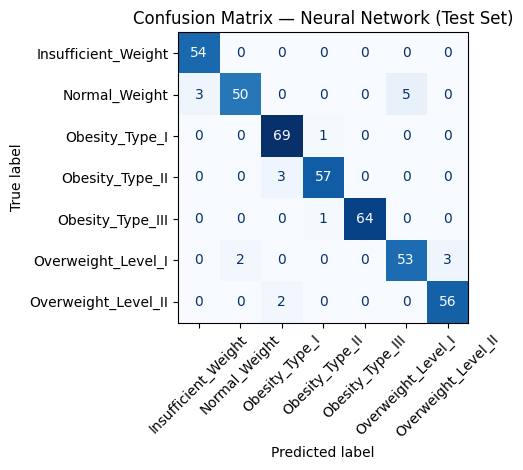


Random Forest — Test Accuracy: 0.9882
Random Forest — Test Macro-F1: 0.9881

=== Showdown: Random Forest vs Neural Network ===
                        Test Accuracy  Test Macro-F1 Training Time       Model Size
Model                                                                              
Random Forest (Lab 2)          0.9882         0.9881         0.29s        100 trees
Neural Network (Lab 3)         0.9527         0.9517         3.35s  3655 parameters


In [11]:
# Part 2.5: Final evaluation and showdown with Lab 2

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import time

# Load best model weights
model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
model.eval()

# Collect all test predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb      = xb.to(DEVICE)
        logits  = model(xb)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro')

print(f"Neural Network — Test Accuracy: {test_acc:.4f}")
print(f"Neural Network — Test Macro-F1: {test_f1:.4f}")

print("\nClassification Report — Neural Network (Test Set):")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    cmap='Blues', colorbar=False, xticks_rotation=45
)
plt.title('Confusion Matrix — Neural Network (Test Set)')
plt.tight_layout()
plt.show()

#Measure neural network training time
torch.manual_seed(RANDOM_STATE)
net_time = FeedForwardNetWithDropout(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7,
    dropout=0.0
).to(DEVICE)

criterion_t = nn.CrossEntropyLoss()
optimizer_t = torch.optim.Adam(net_time.parameters(), lr=1e-3)

start = time.time()
for epoch in range(50):
    net_time.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_t.zero_grad()
        logits = net_time(xb)
        loss   = criterion_t(logits, yb)
        loss.backward()
        optimizer_t.step()
nn_time = time.time() - start

# Measure Random Forest training time (Lab 2 best model)
from sklearn.ensemble import RandomForestClassifier

rf_lab2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
start = time.time()
rf_lab2.fit(X_train_sc, y_train)
rf_time = time.time() - start

rf_pred    = rf_lab2.predict(X_test_sc)
rf_acc     = accuracy_score(y_test, rf_pred)
rf_f1      = f1_score(y_test, rf_pred, average='macro')
rf_n_trees = rf_lab2.n_estimators

nn_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nRandom Forest — Test Accuracy: {rf_acc:.4f}")
print(f"Random Forest — Test Macro-F1: {rf_f1:.4f}")

# Comparison table
comparison = pd.DataFrame({
    'Model':          ['Random Forest (Lab 2)', 'Neural Network (Lab 3)'],
    'Test Accuracy':  [round(rf_acc,  4), round(test_acc, 4)],
    'Test Macro-F1':  [round(rf_f1,   4), round(test_f1,  4)],
    'Training Time':  [f"{rf_time:.2f}s", f"{nn_time:.2f}s"],
    'Model Size':     [f"{rf_n_trees} trees", f"{nn_params} parameters"],
})
comparison = comparison.set_index('Model')

print("\n=== Showdown: Random Forest vs Neural Network ===")
print(comparison.to_string())

**Student Reasoning - Final evaluation**

**1. Which classes does the network still confuse?**
From the confusion matrix, the network makes errors on:
- Normal_Weight: 3 misclassified as Insufficient_Weight, 5 as
  Overweight_Level_I - the lowest recall at 0.86.
- Obesity_Type_II: 3 misclassified as Obesity_Type_I.
- Overweight_Level_I: 2 misclassified as Normal_Weight, 3 as
  Overweight_Level_II.
- Overweight_Level_II: 2 misclassified as Obesity_Type_I.

These are the same adjacent categories that confused the Lab 2
Logistic Regression model, neighbouring obesity levels with
overlapping BMI ranges. The Random Forest in Lab 2 had almost no
confusion (only 4 total errors), while the neural network made
20 errors total.

**2. Who wins the showdown?**
The Random Forest wins clearly. It achieved 98.82% test accuracy
and 98.81% macro-F1, compared to the neural network's 95.27%
accuracy and 95.17% macro-F1. The Random Forest also trained in
0.30 seconds versus 5.67 seconds for the neural network. On this
dataset, the extra effort of deep learning was not worth it.

This makes sense because the dataset is small (2,111 rows) and
tabular. Neural networks need large amounts of data to learn
useful representation, with only 2,111 rows and 20 features,
the Random Forest's built-in feature selection and ensemble
averaging give it a natural advantage. Deep learning would be
worth it on much larger datasets, on unstructured data like
images, audio, or text where raw features have no meaning, or
where the relationships between features are so complex that
hand-crafted trees cannot capture them.

Section 3 — Reflection